# <font color="red">Épisode 3 : CART, agrégation de modèles</font>

Ce notebook reprend l'esprit du TP sur les arbres et les méthodes d'ensemble, en l'appliquant au jeu de données `healthcare_synthetic_data.csv`.

L'objectif est double :
- construire et interpréter un arbre CART pour la classification du risque de maladie cardiaque ;
- comprendre pourquoi des méthodes d'agrégation comme le bagging, les random forests et le boosting améliorent souvent les performances d'un arbre seul.

Le fil directeur est celui du cours : un arbre est un modèle simple, lisible et non paramétrique, mais aussi instable. Les méthodes d'ensemble ont précisément été introduites pour exploiter cette instabilité afin de réduire la variance, et, dans le cas du boosting, aussi une partie du biais.

## 1. Introduction et contexte

Les arbres **CART** (Classification And Regression Trees) ont été popularisés par Breiman, Friedman, Olshen et Stone. Ils construisent une **partition récursive binaire** de l'espace des variables explicatives : à chaque noeud, on choisit une variable et un seuil de coupure afin de créer deux sous-groupes aussi homogènes que possible.

Dans le cadre de la **classification**, l'homogénéité d'un noeud peut être mesurée par des critères comme l'**indice de Gini** ou l'**entropie**. Dans le cadre de la **régression**, le cours insiste sur la réduction de la **variance intra-feuille**. Une fois l'arbre construit, chaque feuille reçoit une prédiction simple : une classe majoritaire en classification, une moyenne locale en régression.

Les arbres sont intéressants pour plusieurs raisons :
- ils sont faciles à visualiser et donc relativement interprétables ;
- ils acceptent naturellement des relations non linéaires et des interactions ;
- ils peuvent traiter des variables de nature différente ;
- ce sont des méthodes **non paramétriques**, donc sans hypothèse linéaire forte.

Leur limite principale est bien soulignée dans les polys : les arbres sont **instables**. Une petite variation des données peut modifier les premières coupures, puis toute la structure du modèle. Cette forte variance peut conduire à du **surapprentissage**, en particulier si l'on laisse croître un arbre très profond.

C'est précisément pour répondre à cette difficulté que les méthodes d'agrégation ont été développées :
- le **bagging** agrège des arbres appris sur des échantillons bootstrap afin de réduire la variance ;
- la **random forest** ajoute une randomisation sur les variables pour diminuer la corrélation entre arbres et renforcer l'effet de réduction de variance ;
- le **boosting** construit séquentiellement un modèle additif, chaque nouvel arbre corrigeant en partie les erreurs du précédent, ce qui peut réduire non seulement la variance mais aussi le biais.

Le poly de boosting présente aussi **XGBoost** comme un prolongement plus industrialisé du gradient boosting. Dans ce notebook, on reste volontairement au niveau du TP et du cours, avec les implémentations `scikit-learn` les plus classiques.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.utils import resample

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

In [2]:
project_dir = Path.cwd()
if not (project_dir / 'divers').exists():
    project_dir = project_dir.parent

data_path = project_dir / 'divers' / 'healthcare_synthetic_data.csv'
healthcare = pd.read_csv(data_path)
healthcare.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 2. Analyse exploratoire

Avant d'ajuster les modèles, on vérifie que la structure du jeu de données est cohérente : dimensions, types, variable cible, éventuelles valeurs manquantes et premières tendances descriptives.

Comme dans un problème médical de classification, il est important de regarder si la cible est déséquilibrée, quelles variables semblent les plus liées au risque, et si certaines distributions présentent déjà des contrastes visibles entre les deux classes.

In [3]:
overview = pd.DataFrame({
    'type': healthcare.dtypes.astype(str),
    'valeurs_manquantes': healthcare.isna().sum(),
    'nb_modalites': healthcare.nunique(),
})

print('Dimensions du jeu de données :', healthcare.shape)
print('\nRépartition de la cible :')
print((healthcare['Heart_Disease_Risk'].value_counts(normalize=True) * 100).round(2))

overview

Dimensions du jeu de données : (15000, 19)

Répartition de la cible :
Heart_Disease_Risk
0    56.4
1    43.6
Name: proportion, dtype: float64


,type,valeurs_manquantes,nb_modalites
Patient_ID,object,0,15000
Age,int64,0,61
Gender,int64,0,2
Height_cm,float64,0,516
Weight_kg,float64,0,817
BMI,float64,0,274
Systolic_BP,int64,0,82
Diastolic_BP,int64,0,61
Cholesterol_Total,int64,0,161
Cholesterol_LDL,int64,0,132


In [4]:
desc = healthcare.describe().T.round(2)
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
Age,54.54,11.88,25.0,46.0,55.0,63.0,85.0
Gender,0.49,0.50,0.0,0.0,0.0,1.0,1.0
Height_cm,165.34,9.19,138.5,158.5,164.7,172.0,198.1
Weight_kg,75.25,14.11,33.7,65.2,73.9,83.9,150.1
BMI,27.45,4.13,14.5,24.5,27.2,30.0,46.1
Systolic_BP,135.12,11.26,90.0,127.0,135.0,143.0,182.0
Diastolic_BP,90.54,8.44,60.0,85.0,91.0,96.0,120.0
Cholesterol_Total,216.25,22.69,127.0,201.0,216.0,231.0,303.0
Cholesterol_LDL,140.36,17.91,70.0,128.0,140.0,152.0,210.0
Cholesterol_HDL,43.31,5.96,20.0,39.0,43.0,47.0,68.0


In [5]:
dfC = healthcare.drop(columns=['Patient_ID', 'Heart_Disease_Risk'])
Yb = healthcare['Heart_Disease_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    dfC,
    Yb,
    test_size=0.25,
    random_state=42,
    stratify=Yb,
)

print('Dimensions apprentissage :', X_train.shape)
print('Dimensions test :', X_test.shape)
print('Taux de classe positive (train) :', round(y_train.mean(), 3))
print('Taux de classe positive (test) :', round(y_test.mean(), 3))

Dimensions apprentissage : (11250, 17)
Dimensions test : (3750, 17)
Taux de classe positive (train) : 0.436
Taux de classe positive (test) : 0.436


In [6]:
results = {}
class_names = ['Risque faible', 'Risque élevé']


def store_result(name, model, fit_time, advantages, limits):
    results[name] = {
        'Modele': name,
        'Accuracy train': round(model.score(X_train, y_train), 4),
        'Accuracy test': round(model.score(X_test, y_test), 4),
        'Erreur test': round(1 - model.score(X_test, y_test), 4),
        'Temps entrainement (s)': round(fit_time, 3),
        'Avantages': advantages,
        'Limites': limits,
    }
    return pd.DataFrame([results[name]])


def plot_confusion(model, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)
    plt.show()

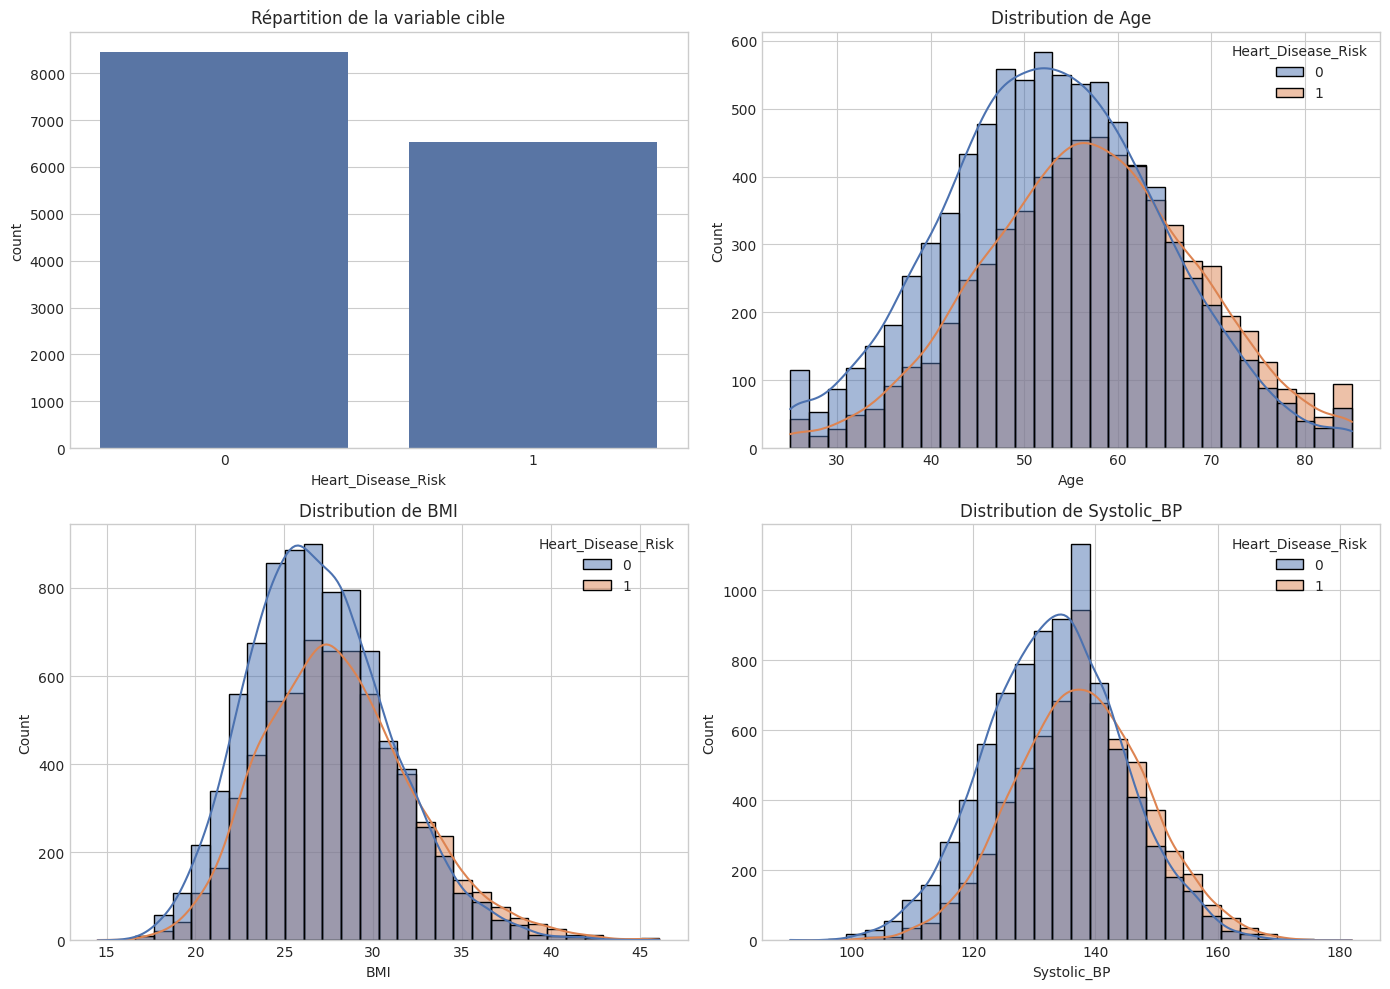

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=healthcare, x='Heart_Disease_Risk', ax=axes[0, 0])
axes[0, 0].set_title('Répartition de la variable cible')
axes[0, 0].set_xlabel('Heart_Disease_Risk')

for ax, col in zip(
    axes.ravel()[1:],
    ['Age', 'BMI', 'Systolic_BP'],
):
    sns.histplot(data=healthcare, x=col, hue='Heart_Disease_Risk', bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

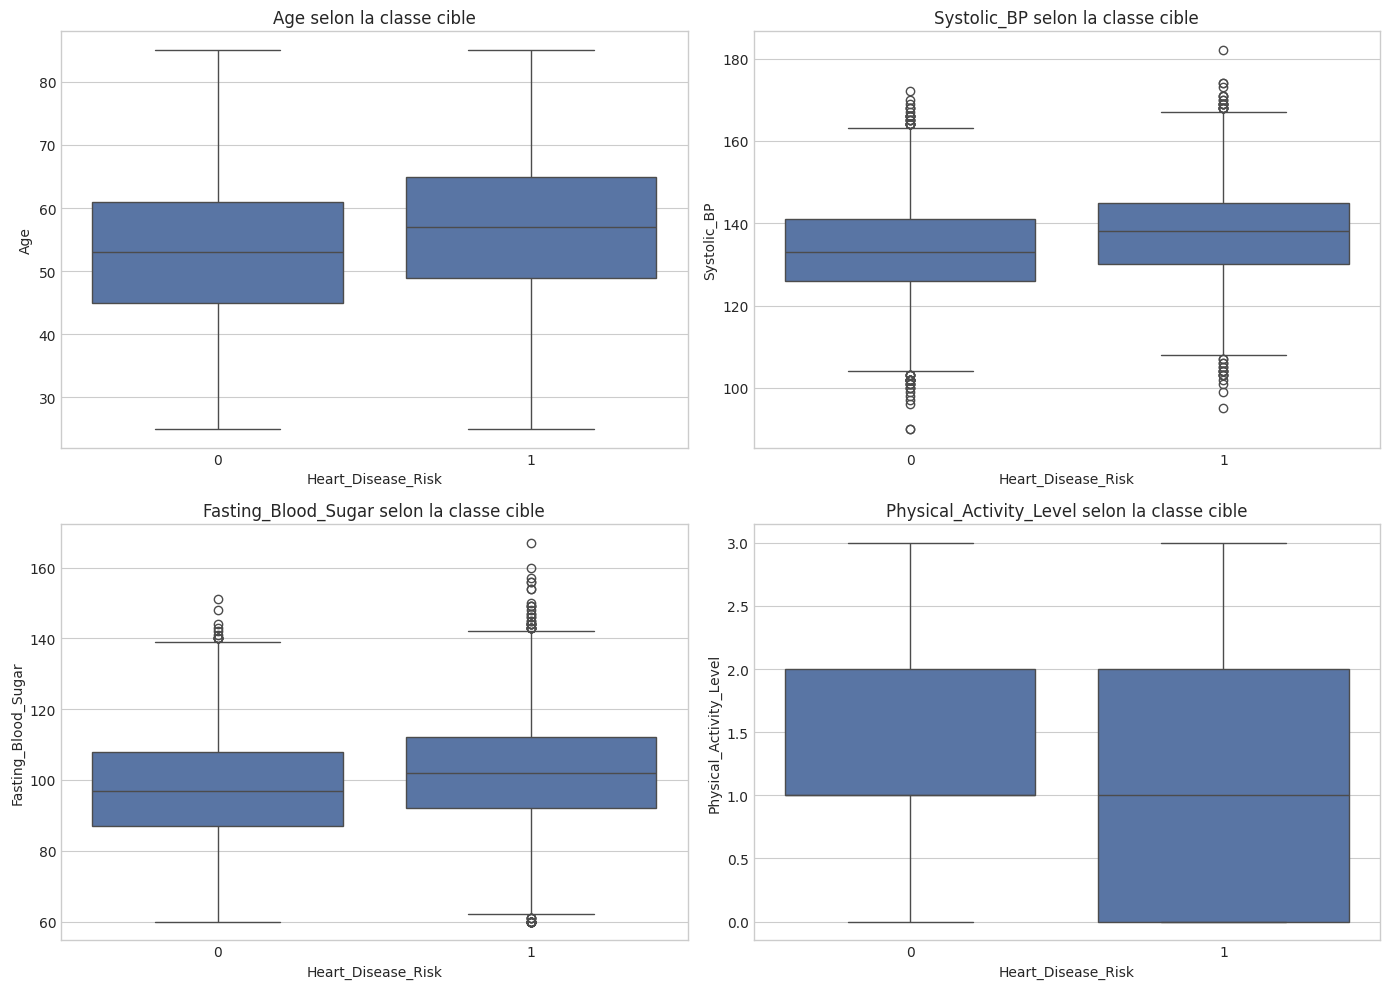

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(
    axes.ravel(),
    ['Age', 'Systolic_BP', 'Fasting_Blood_Sugar', 'Physical_Activity_Level'],
):
    sns.boxplot(data=healthcare, x='Heart_Disease_Risk', y=col, ax=ax)
    ax.set_title(f'{col} selon la classe cible')

plt.tight_layout()
plt.show()

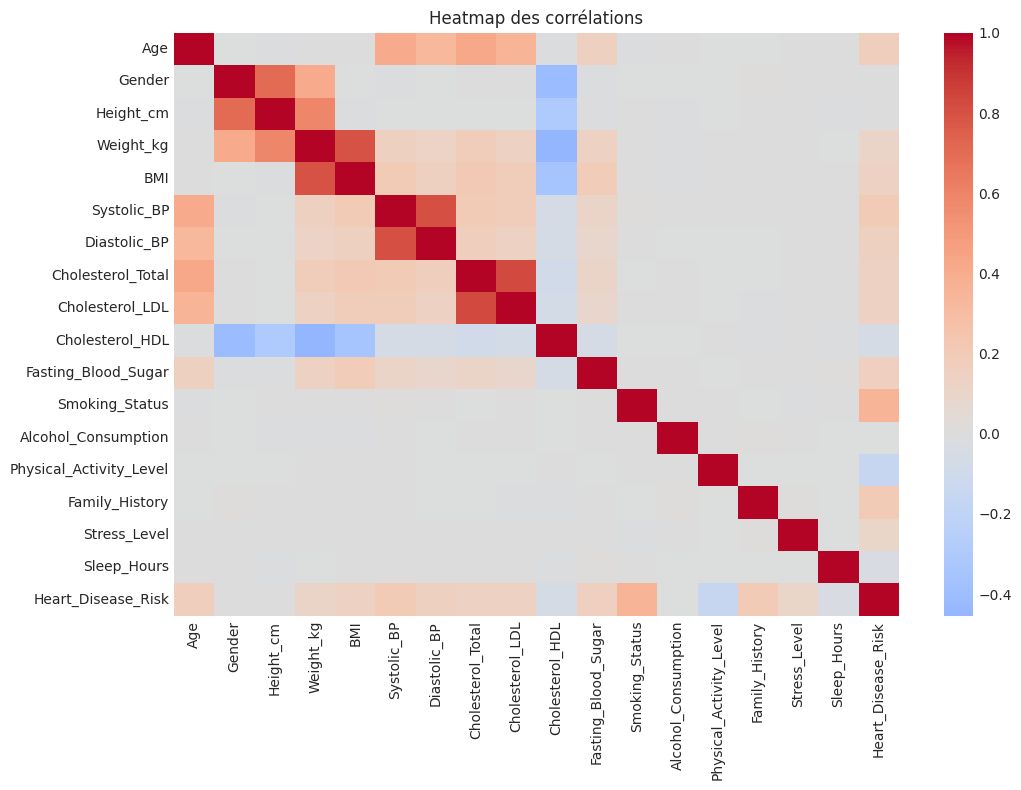

,Corrélation avec la cible
Smoking_Status,0.352467
Family_History,0.201332
Systolic_BP,0.194210
Age,0.168649
Fasting_Blood_Sugar,0.159159
Diastolic_BP,0.154826
Cholesterol_LDL,0.135821
Cholesterol_Total,0.134230
BMI,0.132505
Weight_kg,0.110880


In [9]:
corr = healthcare.drop(columns=['Patient_ID']).corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Heatmap des corrélations')
plt.tight_layout()
plt.show()

corr_target = corr['Heart_Disease_Risk'].drop('Heart_Disease_Risk').sort_values(ascending=False)
corr_target.to_frame('Corrélation avec la cible')

### Lecture de l'EDA

Le jeu de données contient **15 000 observations** et aucune valeur manquante, ce qui simplifie l'analyse. La cible est modérément équilibrée, avec un peu plus de profils à risque faible que de profils à risque élevé, donc l'accuracy reste une métrique lisible ici.

Les graphiques mettent déjà en évidence plusieurs variables plausiblement liées au risque cardiaque :
- `Smoking_Status`, `Family_History`, `Systolic_BP`, `Fasting_Blood_Sugar` et `Age` ressortent comme des variables importantes ;
- `Physical_Activity_Level` semble au contraire corrélée négativement au risque ;
- les distributions restent toutefois assez recouvrantes, ce qui justifie l'usage de modèles capables de capter des interactions et des seuils non linéaires.

Ce cadre est bien adapté à CART : le problème est de classification, les variables sont essentiellement numériques ou codées numériquement, et on s'attend à ce que des coupures successives sur quelques variables médicales structurent la prédiction.

## 3. Partie CART

On commence par l'arbre CART seul, afin de disposer d'un modèle de référence. Conformément au cours, l'arbre est construit par **découpage binaire récursif** : à chaque noeud, on cherche la variable et le seuil qui maximisent le gain d'homogénéité. En classification, `scikit-learn` utilise par défaut l'**indice de Gini**.

L'intérêt pédagogique de CART est qu'il rend visibles les premières divisions du problème. En contrepartie, si l'arbre devient trop profond, il peut mémoriser des détails trop spécifiques à l'échantillon d'apprentissage.

In [10]:
depth_grid = {'max_depth': list(range(1, 13))}
cart_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    depth_grid,
    cv=5,
    n_jobs=-1,
)
cart_search.fit(X_train, y_train)

best_depth = cart_search.best_params_['max_depth']
print('Meilleure profondeur par validation croisée :', best_depth)
print('Accuracy moyenne en CV :', round(cart_search.best_score_, 4))

start = time.perf_counter()
cart_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
cart_model.fit(X_train, y_train)
cart_time = time.perf_counter() - start

print('Accuracy train :', round(cart_model.score(X_train, y_train), 4))
print('Accuracy test :', round(cart_model.score(X_test, y_test), 4))
print('Erreur test :', round(1 - cart_model.score(X_test, y_test), 4))
print('Profondeur retenue :', cart_model.get_depth())
print('Nombre de feuilles :', cart_model.get_n_leaves())

store_result(
    'CART',
    cart_model,
    cart_time,
    "Lisible, rapide et facilement visualisable.",
    "Instable et sensible au surapprentissage si l'arbre devient trop complexe.",
)

Meilleure profondeur par validation croisée : 6
Accuracy moyenne en CV : 0.7126
Accuracy train : 0.7374
Accuracy test : 0.7027
Erreur test : 0.2973
Profondeur retenue : 6
Nombre de feuilles : 57


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,CART,0.7374,0.7027,0.2973,0.035,"Lisible, rapide et facilement visualisable.",Instable et sensible au surapprentissage si l'...


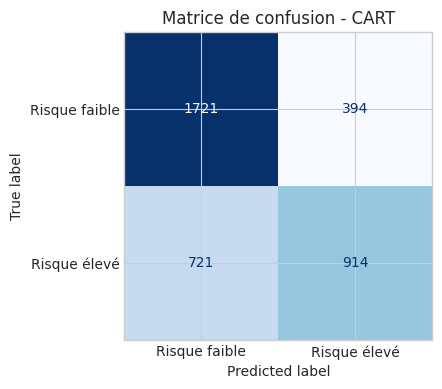

,Importance CART
Smoking_Status,0.472124
Family_History,0.146417
Systolic_BP,0.100207
Physical_Activity_Level,0.074330
Fasting_Blood_Sugar,0.061574
Age,0.043886
BMI,0.028069
Diastolic_BP,0.018895
Cholesterol_Total,0.018349
Stress_Level,0.015305


In [11]:
plot_confusion(cart_model, 'Matrice de confusion - CART')

cart_importances = (
    pd.Series(cart_model.feature_importances_, index=dfC.columns)
    .sort_values(ascending=False)
)
cart_importances.head(10).to_frame('Importance CART')

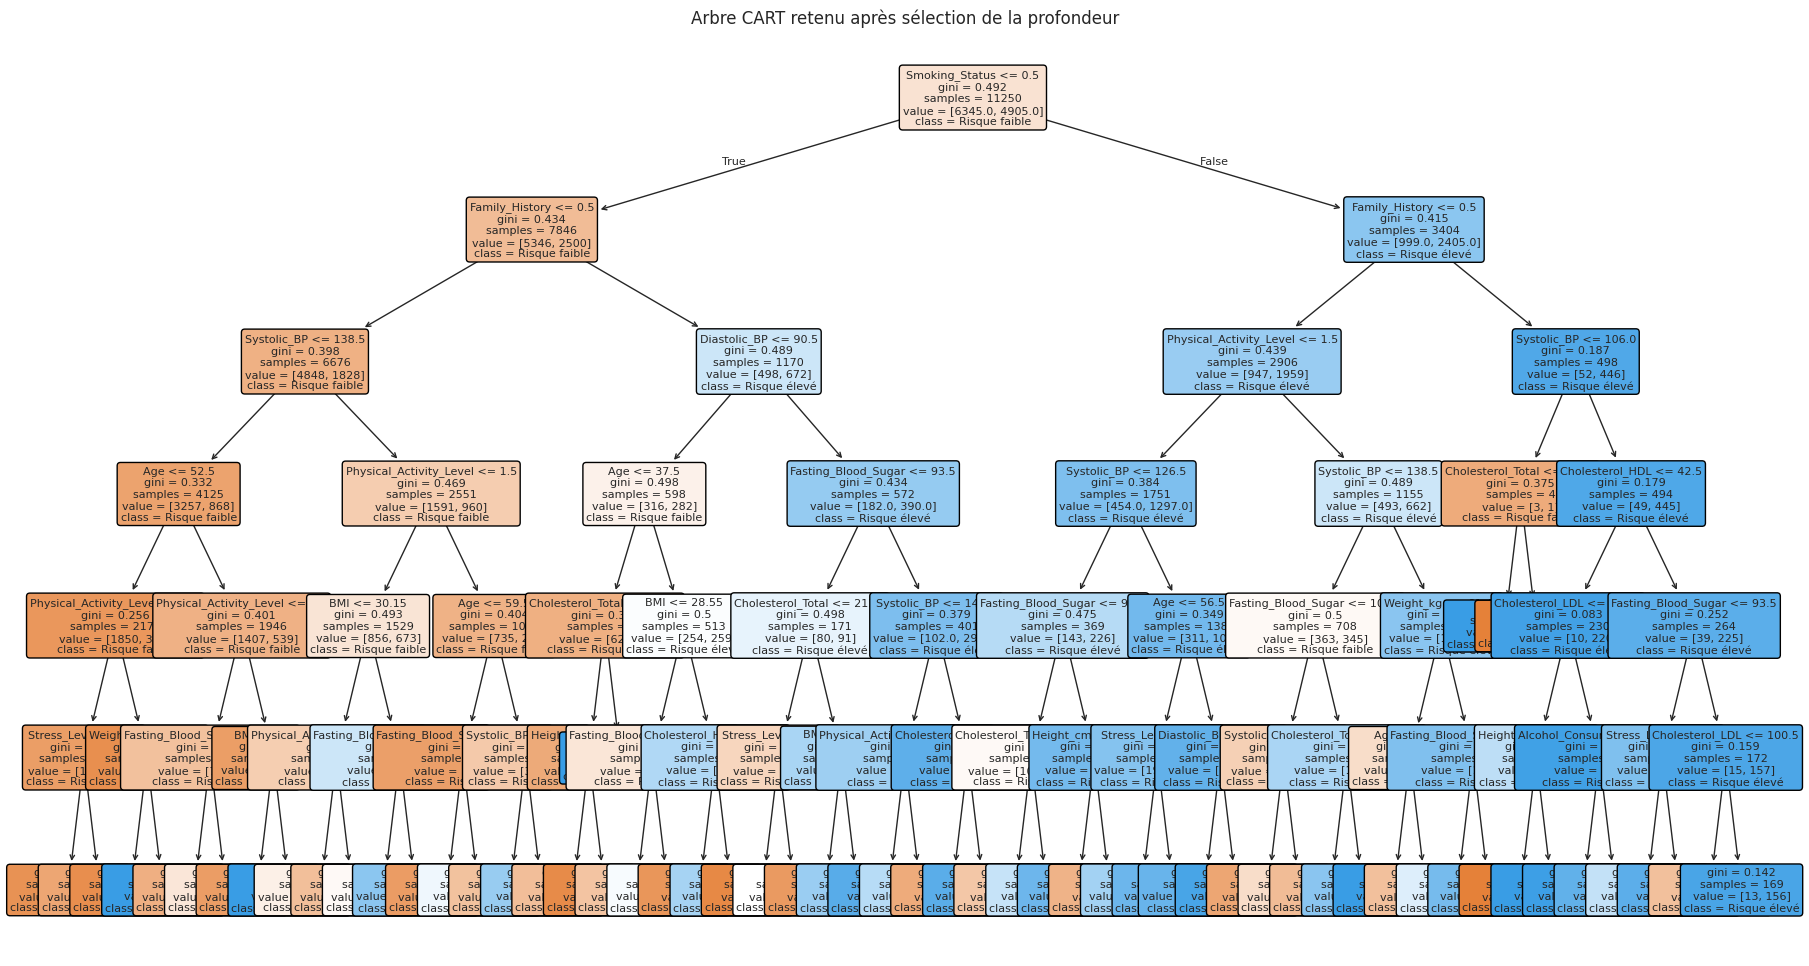

In [12]:
plt.figure(figsize=(22, 12))
plot_tree(
    cart_model,
    feature_names=dfC.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Arbre CART retenu après sélection de la profondeur')
plt.show()

Les premières coupures sont particulièrement intéressantes : elles montrent quelles variables interviennent le plus tôt dans la hiérarchie de décision. En général, une variable placée près de la racine a un effet structurant sur la partition de l'espace.

Il faut néanmoins rester prudent : une coupure haute dans l'arbre n'implique pas une causalité, seulement qu'elle réduit fortement l'hétérogénéité dans cet échantillon.

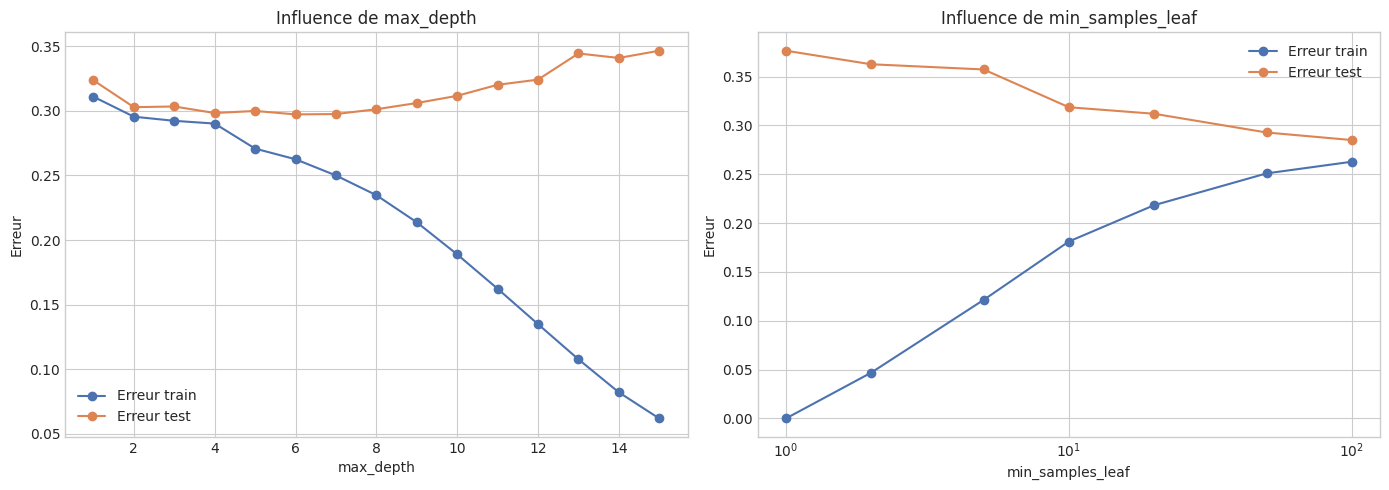

,max_depth,accuracy_train,accuracy_test,nb_feuilles
10,11,0.837689,0.679733,651
11,12,0.865156,0.675733,880
12,13,0.892356,0.655467,1090
13,14,0.917956,0.658933,1318
14,15,0.938222,0.653333,1514


In [13]:
depth_values = list(range(1, 16))
leaf_values = [1, 2, 5, 10, 20, 50, 100]

depth_rows = []
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    depth_rows.append({
        'max_depth': depth,
        'accuracy_train': model.score(X_train, y_train),
        'accuracy_test': model.score(X_test, y_test),
        'nb_feuilles': model.get_n_leaves(),
    })

depth_df = pd.DataFrame(depth_rows)

leaf_rows = []
for leaf in leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    leaf_rows.append({
        'min_samples_leaf': leaf,
        'accuracy_train': model.score(X_train, y_train),
        'accuracy_test': model.score(X_test, y_test),
        'nb_feuilles': model.get_n_leaves(),
    })

leaf_df = pd.DataFrame(leaf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(depth_df['max_depth'], 1 - depth_df['accuracy_train'], marker='o', label='Erreur train')
axes[0].plot(depth_df['max_depth'], 1 - depth_df['accuracy_test'], marker='o', label='Erreur test')
axes[0].set_title("Influence de max_depth")
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Erreur')
axes[0].legend()

axes[1].plot(leaf_df['min_samples_leaf'], 1 - leaf_df['accuracy_train'], marker='o', label='Erreur train')
axes[1].plot(leaf_df['min_samples_leaf'], 1 - leaf_df['accuracy_test'], marker='o', label='Erreur test')
axes[1].set_title("Influence de min_samples_leaf")
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_xscale('log')
axes[1].set_ylabel('Erreur')
axes[1].legend()

plt.tight_layout()
plt.show()

depth_df.tail()

### Complexité, biais et variance

Les courbes précédentes illustrent bien le compromis biais/variance vu en cours :
- quand la profondeur est trop faible ou que `min_samples_leaf` est trop grand, l'arbre est trop rigide et **sous-apprend** ;
- quand la profondeur augmente fortement, l'erreur d'apprentissage continue de diminuer alors que l'erreur test finit par se stabiliser ou se dégrader : c'est le **surapprentissage** ;
- l'écart entre train et test augmente avec la complexité, ce qui traduit la forte variance des arbres.

Cette observation justifie la mise en place d'une procédure d'**élagage** ou, plus simplement, d'un contrôle de complexité.

## 4. Complexité et pruning

Le poly présente le **cost-complexity pruning** comme un compromis entre qualité d'ajustement et parcimonie. On part d'un arbre maximal puis on pénalise le nombre de feuilles par un paramètre `alpha`. Quand `alpha` augmente, certaines branches deviennent trop coûteuses au regard du gain qu'elles apportent, et l'arbre est élagué.

Dans `scikit-learn`, ce mécanisme correspond au paramètre `ccp_alpha`. On sélectionne ici une valeur simple par validation croisée.

In [14]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 0.95, 15)))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pruning_rows = []

for alpha in alpha_grid:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=float(alpha))
    cv_score = cross_val_score(model, X_train, y_train, cv=cv, n_jobs=-1).mean()
    model.fit(X_train, y_train)
    pruning_rows.append({
        'ccp_alpha': float(alpha),
        'accuracy_train': model.score(X_train, y_train),
        'accuracy_test': model.score(X_test, y_test),
        'accuracy_cv': cv_score,
        'nb_feuilles': model.get_n_leaves(),
    })

pruning_df = pd.DataFrame(pruning_rows)
best_alpha = pruning_df.loc[pruning_df['accuracy_cv'].idxmax(), 'ccp_alpha']

start = time.perf_counter()
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=float(best_alpha))
pruned_tree.fit(X_train, y_train)
pruned_time = time.perf_counter() - start

print('Meilleur alpha :', best_alpha)
print('Accuracy CV maximale :', round(pruning_df['accuracy_cv'].max(), 4))
print('Nombre de feuilles après élagage :', pruned_tree.get_n_leaves())
print('Accuracy train :', round(pruned_tree.score(X_train, y_train), 4))
print('Accuracy test :', round(pruned_tree.score(X_test, y_test), 4))

store_result(
    'CART élagué',
    pruned_tree,
    pruned_time,
    "Compromis simple entre interprétabilité et contrôle de la complexité.",
    "Reste plus variable qu'une méthode d'ensemble.",
)

Meilleur alpha : 0.00041937617503812083
Accuracy CV maximale : 0.708
Nombre de feuilles après élagage : 64
Accuracy train : 0.7473
Accuracy test : 0.708


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,CART élagué,0.7473,0.708,0.292,0.085,Compromis simple entre interprétabilité et con...,Reste plus variable qu'une méthode d'ensemble.


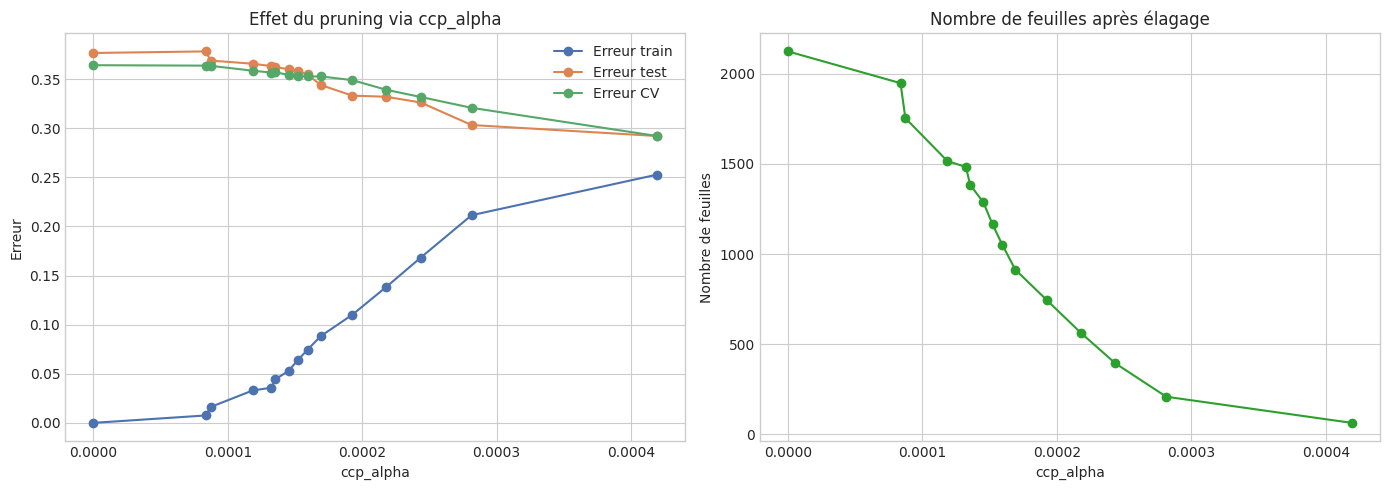

,ccp_alpha,accuracy_train,accuracy_test,accuracy_cv,nb_feuilles
0,0.000000,1.000000,0.623467,0.635911,2124
1,0.000084,0.992444,0.621867,0.636356,1948
2,0.000087,0.983822,0.631200,0.636533,1754
3,0.000119,0.967022,0.634400,0.641511,1516
4,0.000132,0.964178,0.636800,0.643378,1483


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_train'], marker='o', label='Erreur train')
axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_test'], marker='o', label='Erreur test')
axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_cv'], marker='o', label='Erreur CV')
axes[0].set_title('Effet du pruning via ccp_alpha')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Erreur')
axes[0].legend()

axes[1].plot(pruning_df['ccp_alpha'], pruning_df['nb_feuilles'], marker='o', color='tab:green')
axes[1].set_title('Nombre de feuilles après élagage')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Nombre de feuilles')

plt.tight_layout()
plt.show()

pruning_df.head()

L'élagage permet ici de revenir d'un arbre potentiellement trop spécifique vers un arbre plus parcimonieux. On retrouve exactement la logique du cours : on ne cherche pas l'arbre qui ajuste le mieux les données d'apprentissage, mais celui qui offre le meilleur compromis entre ajustement et complexité.

En pratique, l'arbre élagué reste interprétable, tout en limitant légèrement le surapprentissage.

## 5. Bagging

Le **bagging** (bootstrap aggregating) consiste à construire plusieurs arbres sur des échantillons bootstrap puis à agréger leurs prédictions par vote majoritaire. Le principe théorique du cours est simple : en agrégeant des prédictions peu corrélées, on réduit la **variance** du prédicteur final.

Cette idée est particulièrement adaptée aux arbres car ils sont instables. Le bagging n'améliore donc pas l'interprétabilité, mais il vise une meilleure **stabilité** et souvent une meilleure généralisation.

In [16]:
start = time.perf_counter()
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
bagging_model.fit(X_train, y_train)
bagging_time = time.perf_counter() - start

print('Score OOB :', round(bagging_model.oob_score_, 4))
print('Accuracy train :', round(bagging_model.score(X_train, y_train), 4))
print('Accuracy test :', round(bagging_model.score(X_test, y_test), 4))
print('Erreur test :', round(1 - bagging_model.score(X_test, y_test), 4))

store_result(
    'Bagging',
    bagging_model,
    bagging_time,
    "Réduction de variance et meilleure stabilité qu'un arbre seul.",
    "Interprétation globale beaucoup moins directe qu'un CART.",
)

Score OOB : 0.7235
Accuracy train : 1.0
Accuracy test : 0.7184
Erreur test : 0.2816


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,Bagging,1.0,0.7184,0.2816,2.862,Réduction de variance et meilleure stabilité q...,Interprétation globale beaucoup moins directe ...


                mean     std
Modele                      
Arbre unique  0.6264  0.0079
Bagging       0.7146  0.0033


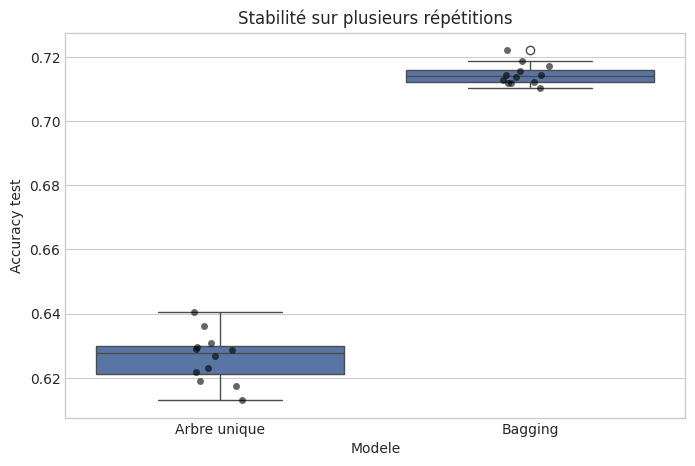

In [17]:
stability_rows = []
for seed in range(12):
    X_boot, y_boot = resample(
        X_train,
        y_train,
        replace=True,
        n_samples=len(X_train),
        random_state=seed,
    )

    tree_boot = DecisionTreeClassifier(random_state=seed)
    tree_boot.fit(X_boot, y_boot)
    stability_rows.append({
        'Modele': 'Arbre unique',
        'Accuracy test': tree_boot.score(X_test, y_test),
    })

    bag_boot = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=seed),
        n_estimators=80,
        bootstrap=True,
        random_state=seed,
        n_jobs=-1,
    )
    bag_boot.fit(X_train, y_train)
    stability_rows.append({
        'Modele': 'Bagging',
        'Accuracy test': bag_boot.score(X_test, y_test),
    })

stability_df = pd.DataFrame(stability_rows)
print(stability_df.groupby('Modele')['Accuracy test'].agg(['mean', 'std']).round(4))

plt.figure(figsize=(8, 5))
sns.boxplot(data=stability_df, x='Modele', y='Accuracy test')
sns.stripplot(data=stability_df, x='Modele', y='Accuracy test', color='black', alpha=0.6)
plt.title('Stabilité sur plusieurs répétitions')
plt.show()

Le bagging confirme bien l'idée du cours : même si chaque arbre de base est très variable, leur vote moyen est plus stable. La dispersion des performances est plus faible que pour un arbre isolé, et l'accuracy test progresse en général.

On paie cette amélioration par une perte d'interprétabilité : on ne dispose plus d'un seul arbre lisible, mais d'une moyenne de nombreux arbres.

## 6. Random Forest

La **random forest** reprend le bagging mais ajoute une randomisation supplémentaire : à chaque noeud, l'algorithme ne cherche pas la meilleure coupure parmi toutes les variables, mais parmi un sous-ensemble aléatoire de variables.

Cette idée est centrale dans le poly : elle diminue la **corrélation entre arbres**. Chaque arbre est un peu moins optimal pris isolément, mais l'ensemble devient plus efficace grâce à une réduction de variance plus forte.

On étudie ici trois hyperparamètres simples :
- `n_estimators` : nombre d'arbres ;
- `max_depth` : profondeur maximale ;
- `max_features` : nombre de variables candidates à chaque noeud.

In [18]:
rf_search = GridSearchCV(
    RandomForestClassifier(
        n_estimators=150,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'max_depth': [None, 6, 10],
        'max_features': [3, 4, 'sqrt', None],
    },
    cv=5,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print('Meilleurs paramètres :', rf_search.best_params_)
print('Accuracy moyenne en CV :', round(rf_search.best_score_, 4))

Meilleurs paramètres : {'max_depth': 10, 'max_features': 4}
Accuracy moyenne en CV : 0.7316


In [19]:
rf_curve_rows = []
for n_trees in [50, 100, 200, 400]:
    rf_tmp = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=rf_search.best_params_['max_depth'],
        max_features=rf_search.best_params_['max_features'],
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    rf_tmp.fit(X_train, y_train)
    rf_curve_rows.append({
        'n_estimators': n_trees,
        'Erreur OOB': 1 - rf_tmp.oob_score_,
        'Erreur test': 1 - rf_tmp.score(X_test, y_test),
    })

rf_curve_df = pd.DataFrame(rf_curve_rows)
rf_curve_df

,n_estimators,Erreur OOB,Erreur test
0,50,0.273067,0.278400
1,100,0.271556,0.275467
2,200,0.268889,0.279467
3,400,0.268444,0.278400


In [20]:
start = time.perf_counter()
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=rf_search.best_params_['max_depth'],
    max_features=rf_search.best_params_['max_features'],
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_time = time.perf_counter() - start

print('Score OOB :', round(rf_model.oob_score_, 4))
print('Accuracy train :', round(rf_model.score(X_train, y_train), 4))
print('Accuracy test :', round(rf_model.score(X_test, y_test), 4))
print('Erreur test :', round(1 - rf_model.score(X_test, y_test), 4))

store_result(
    'Random Forest',
    rf_model,
    rf_time,
    "Bonne robustesse et réduction de variance grâce au bootstrap et à la randomisation des variables.",
    "Boîte noire plus difficile à interpréter qu'un arbre unique.",
)

Score OOB : 0.7315
Accuracy train : 0.8419
Accuracy test : 0.7192
Erreur test : 0.2808


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,Random Forest,0.8419,0.7192,0.2808,1.309,Bonne robustesse et réduction de variance grâc...,Boîte noire plus difficile à interpréter qu'un...


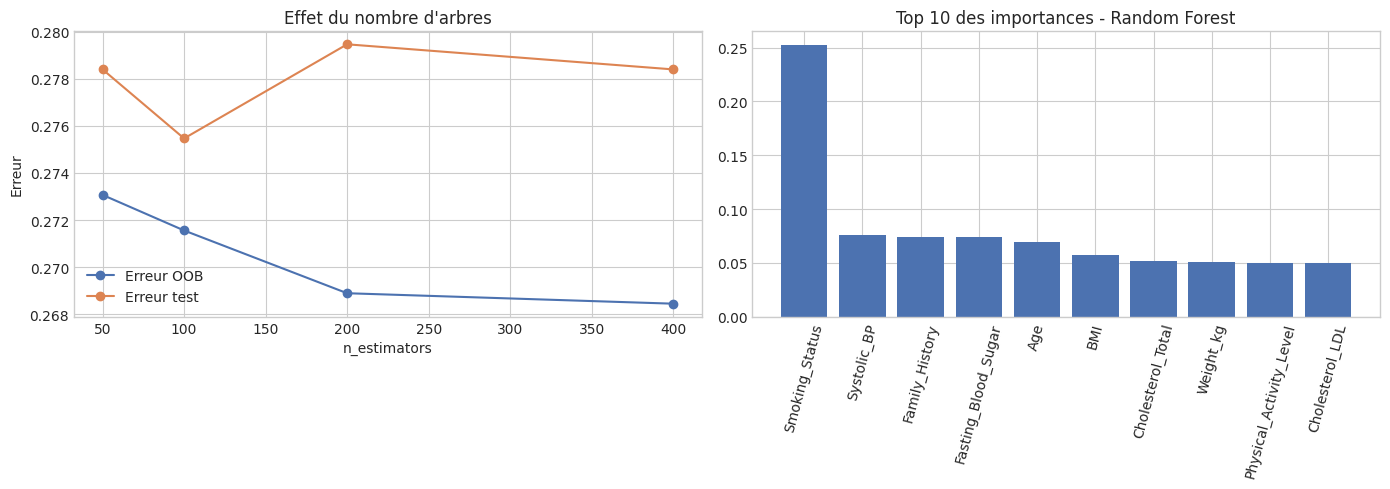

,Importance RF
Smoking_Status,0.252438
Systolic_BP,0.075794
Family_History,0.073781
Fasting_Blood_Sugar,0.073610
Age,0.069082
BMI,0.057387
Cholesterol_Total,0.051326
Weight_kg,0.051053
Physical_Activity_Level,0.049975
Cholesterol_LDL,0.049705


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['Erreur OOB'], marker='o', label='Erreur OOB')
axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['Erreur test'], marker='o', label='Erreur test')
axes[0].set_title("Effet du nombre d'arbres")
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Erreur')
axes[0].legend()

rf_importances = (
    pd.Series(rf_model.feature_importances_, index=dfC.columns)
    .sort_values(ascending=False)
)
axes[1].bar(rf_importances.head(10).index, rf_importances.head(10).values)
axes[1].set_title('Top 10 des importances - Random Forest')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

rf_importances.head(10).to_frame('Importance RF')

La forêt aléatoire illustre bien la phrase du cours : **les arbres sont interprétables mais instables ; les forêts réduisent cette variance au prix d'une perte d'interprétabilité**.

Les performances progressent généralement par rapport à CART seul, puis se stabilisent quand le nombre d'arbres devient suffisamment grand. Les importances de variables sont utiles pour guider la lecture, mais il faut garder une idée simple : **importance n'est pas causalité**. Une variable peut être très utilisée pour prédire sans être une cause directe du phénomène.

## 7. Boosting

Le **boosting** diffère profondément du bagging. Au lieu de construire des modèles indépendants en parallèle, il construit un **modèle additif séquentiel** : chaque nouvel arbre cherche à corriger les erreurs du modèle précédent.

Dans l'esprit du cours :
- **AdaBoost** augmente le poids des observations mal classées ;
- **Gradient Boosting** ajuste successivement de petits arbres sur les **résidus** ou, plus généralement, sur des pseudo-résidus issus du gradient de la fonction de perte.

Le boosting peut donc réduire la variance, mais aussi une partie du **biais**. En revanche, si on multiplie trop les itérations, on risque de surapprendre. Le cours insiste alors sur deux idées simples :
- le **learning rate** (ou shrinkage) ;
- l'**early stopping**, c'est-à-dire l'arrêt avant que l'erreur de validation ne remonte.

In [22]:
ada_search = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42,
    ),
    {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.5, 1.0],
    },
    cv=5,
    n_jobs=-1,
)
ada_search.fit(X_train, y_train)

start = time.perf_counter()
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=ada_search.best_params_['n_estimators'],
    learning_rate=ada_search.best_params_['learning_rate'],
    random_state=42,
)
ada_model.fit(X_train, y_train)
ada_time = time.perf_counter() - start

print('Meilleurs paramètres AdaBoost :', ada_search.best_params_)
print('Accuracy moyenne en CV :', round(ada_search.best_score_, 4))
print('Accuracy train :', round(ada_model.score(X_train, y_train), 4))
print('Accuracy test :', round(ada_model.score(X_test, y_test), 4))

store_result(
    'AdaBoost',
    ada_model,
    ada_time,
    "Procédure séquentielle souvent performante avec des arbres faibles.",
    "Plus sensible au réglage du nombre d'itérations et du learning rate.",
)

Meilleurs paramètres AdaBoost : {'learning_rate': 0.5, 'n_estimators': 200}
Accuracy moyenne en CV : 0.7366
Accuracy train : 0.7384
Accuracy test : 0.7301


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,AdaBoost,0.7384,0.7301,0.2699,1.615,Procédure séquentielle souvent performante ave...,Plus sensible au réglage du nombre d'itération...


In [23]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

gb_rows = []
gb_histories = {}

for learning_rate in [0.05, 0.1]:
    for max_depth in [1, 2, 3]:
        gb_tmp = GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=learning_rate,
            max_depth=max_depth,
            random_state=42,
        )
        gb_tmp.fit(X_subtrain, y_subtrain)

        train_scores = []
        val_scores = []
        for pred_train, pred_val in zip(
            gb_tmp.staged_predict(X_subtrain),
            gb_tmp.staged_predict(X_val),
        ):
            train_scores.append(accuracy_score(y_subtrain, pred_train))
            val_scores.append(accuracy_score(y_val, pred_val))

        best_iter = int(np.argmax(val_scores)) + 1
        best_val = float(np.max(val_scores))
        gb_histories[(learning_rate, max_depth)] = {
            'train_scores': train_scores,
            'val_scores': val_scores,
            'best_iter': best_iter,
            'best_val': best_val,
        }
        gb_rows.append({
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'best_iter': best_iter,
            'best_val_accuracy': best_val,
        })

gb_tuning_df = pd.DataFrame(gb_rows).sort_values('best_val_accuracy', ascending=False)
gb_tuning_df

,learning_rate,max_depth,best_iter,best_val_accuracy
4,0.10,2,123,0.740444
5,0.10,3,75,0.737778
3,0.10,1,159,0.736000
1,0.05,2,218,0.736000
2,0.05,3,179,0.735556
0,0.05,1,247,0.731111


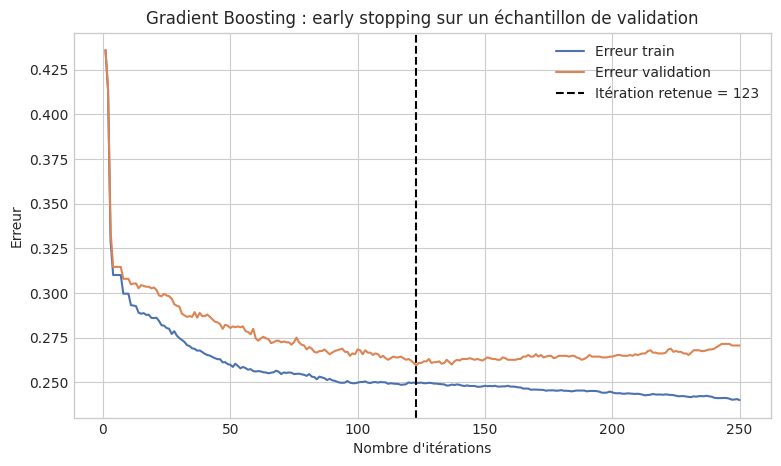

Meilleure configuration : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 123}
Accuracy train : 0.75
Accuracy test : 0.7259


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
0,Gradient Boosting,0.75,0.7259,0.2741,1.385,Réduction séquentielle des erreurs avec contrô...,Peut surapprendre si l'on choisit trop d'itéra...


In [24]:
best_gb = gb_tuning_df.iloc[0]
best_lr = float(best_gb['learning_rate'])
best_depth = int(best_gb['max_depth'])
best_iter = int(best_gb['best_iter'])

start = time.perf_counter()
gb_model = GradientBoostingClassifier(
    n_estimators=best_iter,
    learning_rate=best_lr,
    max_depth=best_depth,
    random_state=42,
)
gb_model.fit(X_train, y_train)
gb_time = time.perf_counter() - start

history = gb_histories[(best_lr, best_depth)]
iterations = np.arange(1, len(history['train_scores']) + 1)

plt.figure(figsize=(9, 5))
plt.plot(iterations, 1 - np.array(history['train_scores']), label='Erreur train')
plt.plot(iterations, 1 - np.array(history['val_scores']), label='Erreur validation')
plt.axvline(best_iter, color='black', linestyle='--', label=f'Itération retenue = {best_iter}')
plt.title('Gradient Boosting : early stopping sur un échantillon de validation')
plt.xlabel('Nombre d\'itérations')
plt.ylabel('Erreur')
plt.legend()
plt.show()

print('Meilleure configuration :', {'learning_rate': best_lr, 'max_depth': best_depth, 'n_estimators': best_iter})
print('Accuracy train :', round(gb_model.score(X_train, y_train), 4))
print('Accuracy test :', round(gb_model.score(X_test, y_test), 4))

store_result(
    'Gradient Boosting',
    gb_model,
    gb_time,
    "Réduction séquentielle des erreurs avec contrôle par learning rate et early stopping.",
    "Peut surapprendre si l'on choisit trop d'itérations ou des arbres trop complexes.",
)

La différence conceptuelle avec la random forest apparaît bien ici :
- la random forest agrège des arbres construits en parallèle pour réduire surtout la **variance** ;
- le boosting construit un modèle séquentiel qui cherche à corriger progressivement les erreurs, ce qui peut aussi réduire le **biais**.

Dans ce jeu de données, le boosting peut obtenir de très bonnes performances, mais il demande un réglage plus fin. Les paramètres `learning_rate`, `n_estimators` et la profondeur des petits arbres jouent un rôle central.

## 8. Comparaison globale des modèles

On rassemble maintenant les principaux résultats pour comparer les approches sous plusieurs angles : qualité d'ajustement, généralisation, temps d'entraînement, interprétabilité et stabilité.

In [25]:
comparison_df = pd.DataFrame(results).T.sort_values('Accuracy test', ascending=False)
comparison_df

,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s),Avantages,Limites
AdaBoost,AdaBoost,0.7384,0.7301,0.2699,1.615,Procédure séquentielle souvent performante ave...,Plus sensible au réglage du nombre d'itération...
Gradient Boosting,Gradient Boosting,0.75,0.7259,0.2741,1.385,Réduction séquentielle des erreurs avec contrô...,Peut surapprendre si l'on choisit trop d'itéra...
Random Forest,Random Forest,0.8419,0.7192,0.2808,1.309,Bonne robustesse et réduction de variance grâc...,Boîte noire plus difficile à interpréter qu'un...
Bagging,Bagging,1.0,0.7184,0.2816,2.862,Réduction de variance et meilleure stabilité q...,Interprétation globale beaucoup moins directe ...
CART élagué,CART élagué,0.7473,0.708,0.292,0.085,Compromis simple entre interprétabilité et con...,Reste plus variable qu'une méthode d'ensemble.
CART,CART,0.7374,0.7027,0.2973,0.035,"Lisible, rapide et facilement visualisable.",Instable et sensible au surapprentissage si l'...


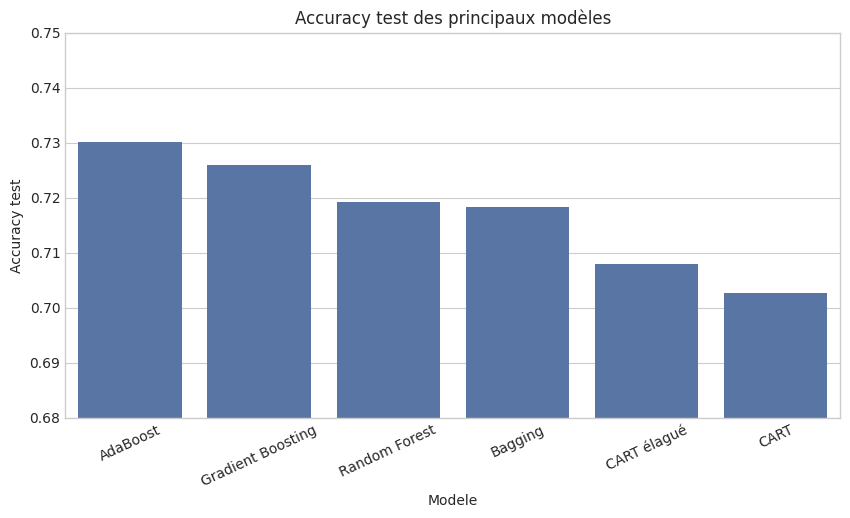

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df.reset_index(drop=True), x='Modele', y='Accuracy test')
plt.ylim(0.68, 0.75)
plt.title('Accuracy test des principaux modèles')
plt.xticks(rotation=25)
plt.show()

### Analyse comparative

Quelques tendances fortes se dégagent :
- **CART** est le plus lisible, mais aussi le plus sensible à la complexité et à la variance ;
- le **pruning** améliore le compromis complexité / généralisation sans changer la philosophie du modèle ;
- le **bagging** stabilise nettement les performances en agrégeant des arbres instables appris sur des échantillons bootstrap ;
- la **random forest** va plus loin en décorrélant les arbres grâce à la randomisation des variables ;
- le **boosting** est conceptuellement différent : il ne moyenne pas seulement des modèles, il les construit de façon séquentielle pour corriger les erreurs passées.

On retrouve donc le message du cours : les méthodes d'ensemble améliorent la qualité prédictive des arbres, mais au prix d'une perte d'interprétabilité globale.

## 9. Conclusion finale

Ce TP montre bien pourquoi les arbres restent des outils très importants en machine learning. Un **CART** fournit une lecture intuitive du problème grâce à ses coupures successives, mais il présente une forte variance et peut surapprendre rapidement si l'on ne contrôle pas sa complexité.

Les méthodes d'agrégation répondent directement à cette faiblesse :
- le **bagging** réduit la variance en moyennant des arbres appris sur des échantillons bootstrap ;
- la **random forest** réduit encore la variance en diminuant la corrélation entre arbres grâce au tirage aléatoire des variables ;
- le **boosting** adopte une autre philosophie, en construisant un modèle additif séquentiel qui corrige progressivement les erreurs précédentes, avec un effet possible sur la variance mais aussi sur le biais.

Sur le plan pratique, ces méthodes sont souvent plus performantes qu'un arbre seul, mais elles imposent plusieurs précautions :
- régler les hyperparamètres avec soin (`max_depth`, `min_samples_leaf`, `max_features`, `n_estimators`, `learning_rate`) ;
- surveiller le surapprentissage, notamment pour le boosting ;
- rester prudent dans l'interprétation des importances de variables ;
- accepter le compromis classique entre **interprétabilité** et **performance**.

Au total, le notebook confirme bien l'idée centrale des polys : un arbre seul est un bon point de départ pour comprendre le problème, tandis que l'agrégation permet de construire des modèles plus robustes et souvent plus précis.